# TP 1 : Implémentation d'un RNN from scratch et application à une série temporelle réelle

Installation des librairies

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

### Partie 1 : Implémentation d'un RNN from scratch.

1. Écrire une fonction qui calcule l'état caché de h_t en fonction de x_t, de l'état caché précédent, et des poids de la cellule RNN.

In [35]:
def forward_hidden_state(x_t, h_prev, W_xh, W_hh, b_h):
    h_t = np.tanh(W_xh @ x_t + W_hh @ h_prev + b_h)
    return h_t

2. Écrire une fonction qui calcule la sortie y_t de la cellule en fonction de h_t, et des poids de la cellule RNN.

In [36]:
def output(h_t, W_hy, b_y):
    return y_t


3. Regrouper les fonctions précédentes dans une fonction globale, qui calcule l'état caché et la sortie de la cellulle au pas de temps t.

In [37]:
def forward_rnn_cell(x_t, h_prev, W_xh, W_hh, b_h, W_hy, b_y):
    h_t = forward_hidden_state(x_t, h_prev, W_xh, W_hh, b_h)
    y_t = W_hy @ h_t + b_y
    return h_t, y_t

4. Pour une série temporelle X de longueur T, écrire la fonction qui fait passer cette entrée dans la cellule RNN, et retourne les états cachés et les sorties sur l'ensemble des pas de temps.

In [38]:
def forward_rnn(X, h0, W_xh, W_hh, b_h, W_hy, b_y):
    H = [h0]
    Y = []
    for x_t in X:
        # Calcul de l'état caché
        h_t = np.tanh(x_t @ W_xh + H[-1] @ W_hh + b_h)
        # Calcul de la sortie
        y_t = h_t @ W_hy + b_y
        H.append(h_t)
        Y.append(y_t)

    H = np.array(H[1:])
    Y = np.array(Y)
    return Y, H

### Partie 2 : Application à l'exemple du TD (Inférence)

5. Vérifier votre modèle en l'appliquant avec les poids du réseau du TD1, réalisé à la main.

In [39]:
import numpy as np

# Données
x_1 = np.array([[0.5], [-0.3]])
x_2 = np.array([[-0.1], [0.7]])
X   = np.array([x_1, x_2])

# Paramètres
W_xh = np.array([[0.1, 0.2], [-0.3, 0.4], [0.5, -0.2]])
W_hh = np.array([[0.2, -0.1, 0.3], [0.4, 0.5, -0.2], [-0.3, 0.1, 0.2]])
W_hy = np.array([[0.7, -0.5, 0.6]])
b_h  = np.array([[0.1], [-0.2], [0.1]])
b_y  = np.array([[0.1]])
h0   = np.array([[0.0], [0.0], [0.0]])

# Forward pass
def forward_rnn(X, h0, W_xh, W_hh, b_h, W_hy, b_y):
    H = []
    Y_pred = []
    h_prev = h0
    for x_t in X:
        h_t = np.tanh(W_xh @ x_t + W_hh @ h_prev + b_h)
        y_t = W_hy @ h_t + b_y
        H.append(h_t)
        Y_pred.append(y_t)
        h_prev = h_t
    return Y_pred, H

# Résultats
Y_pred, H = forward_rnn(X, h0, W_xh, W_hh, b_h, W_hy, b_y)

print(f"h1 : {H[0].T}")
print(f"y1 : {Y_pred[0]}")
print(f"h2 : {H[1].T}")
print(f"y2 : {Y_pred[1]}")

h1 : [[ 0.08975778 -0.43819931  0.38847268]]
y1 : [[0.61501371]]
h2 : [[ 0.38703958 -0.14975625 -0.0828623 ]]
y2 : [[0.39608845]]


### Partie 3 : Implémentation de l'optimisation du RNN

6. Écrire une fonction qui calcule l'erreur quadratique entre une séquence prédite et une séquence réelle.

In [40]:
def compute_loss(Y_pred, Y_true):
    Y_pred_arr = np.array(Y_pred)
    Y_true_arr = np.array(Y_true)
    loss = np.mean((Y_pred_arr - Y_true_arr) ** 2)
    return loss

7. Calcul du gradient du RNN - Compléter la foncton suivante en vous aidant du gradient calculé en séance de TD.

In [41]:
def compute_gradients(X, Y_true, H, Y_pred, W_xh, W_hh, b_h, W_hy, b_y):
    dL_dW_xh = np.zeros_like(W_xh)
    dL_dW_hh = np.zeros_like(W_hh)
    dL_db_h = np.zeros_like(b_h)
    dL_dW_hy = np.zeros_like(W_hy)
    dL_db_y = np.zeros_like(b_y)
    dL_dh_next = np.zeros_like(H[0])

    N = len(X)

    for t in reversed(range(N)):
        dy = (2 / N) * (Y_pred[t] - Y_true[t])

        dL_dW_hy += dy * H[t].T
        dL_db_y += dy

        dh = W_hy.T * dy + dL_dh_next
        dtanh = (1 - H[t] ** 2) * dh

        dL_db_h += dtanh
        dL_dW_xh += dtanh @ X[t].T
        dL_dW_hh += dtanh @ (H[t - 1].T if t > 0 else np.zeros_like(H[0]).T)
        dL_dh_next = W_hh.T @ dtanh

    gradients = [dL_dW_xh, dL_dW_hh, dL_db_h, dL_dW_hy, dL_db_y]
    return [np.clip(g, -0.5, 0.5) for g in gradients]

test

In [42]:
Y_true = [np.array([[0.42]]), np.array([[0.5]])]

loss = compute_loss(Y_pred, Y_true)
print(f"Loss : {loss:.4f}")

gradients = compute_gradients(X, Y_true, H, Y_pred, W_xh, W_hh, b_h, W_hy, b_y)
noms = ["dL_dW_xh", "dL_dW_hh", "dL_db_h", "dL_dW_hy", "dL_db_y"]
for nom, g in zip(noms, gradients):
    print(f"{nom} :\n{g}\n")

Loss : 0.0244
dL_dW_xh :
[[ 0.08704401 -0.09180525]
 [-0.03421457  0.0530347 ]
 [ 0.03842065 -0.06268045]]

dL_dW_hh :
[[-0.0055508   0.0270991  -0.02402391]
 [ 0.00455885 -0.02225639  0.01973075]
 [-0.0055577   0.0271328  -0.02405378]]

dL_db_h :
[[ 0.09987768]
 [-0.00748045]
 [ 0.00253869]]

dL_dW_hy :
[[-0.02271388 -0.06989347  0.08436785]]

dL_db_y :
[[0.09110216]]



8. Écrire une fonction qui mets à jour les poids du réseau de neurones en utilisant la fonction de calcul des gradients.

In [43]:
def update_weights(
    X_train, Y_train, h0, W_xh, W_hh, b_h, W_hy, b_y, learning_rate
):
    # Calcul des sorties du réseau
    Y_pred, H = forward_rnn(X_train, h0, W_xh, W_hh, b_h, W_hy, b_y)

    # Calcul et affichage de la loss (MSE)
    loss = compute_loss(Y_pred, Y_train)
    print(f"Loss: {loss}")

    # Récupération des gradients
    dL_dW_xh, dL_dW_hh, dL_db_h, dL_dW_hy, dL_db_y = compute_gradients(
        X_train, Y_train, H, Y_pred, W_xh, W_hh, b_h, W_hy, b_y
    )

    # Mise à jour des poids (gradient descent)
    W_xh_new = W_xh - learning_rate * dL_dW_xh
    W_hh_new = W_hh - learning_rate * dL_dW_hh
    b_h_new  = b_h  - learning_rate * dL_db_h
    W_hy_new = W_hy - learning_rate * dL_dW_hy
    b_y_new  = b_y  - learning_rate * dL_db_y

    return W_xh_new, W_hh_new, b_h_new, W_hy_new, b_y_new

9. Écrire une fonction qui optimise le RNN en réalisant la mise à jour des poids pour un nombre d'époques donné.

In [44]:
def optimize_rnn(X_train, Y_train, h0, W_xh, W_hh, b_h, W_hy, b_y, epochs, learning_rate):
    for epoch in range(epochs):
        W_xh, W_hh, b_h, W_hy, b_y = update_weights(
            X_train, Y_train, h0, W_xh, W_hh, b_h, W_hy, b_y, learning_rate
        )
        if epoch % 10 == 0:
            Y_pred, _ = forward_rnn(X_train, h0, W_xh, W_hh, b_h, W_hy, b_y)
            loss = compute_loss(Y_pred, Y_train)
            print(f"Epoch {epoch}/{epochs} - Loss: {loss:.4f}")

    return W_xh, W_hh, b_h, W_hy, b_y

### Partie 4 : Application à l'exemple du TD (Optimisation)

10. Optimisation du réseau sur l'exemple du TD - Utiliser les valeurs rélles du TD pour optimiser le RNN.

In [45]:
# Données
x_1 = np.array([[0.5], [-0.3]])
x_2 = np.array([[-0.1], [0.7]])
X = np.array([x_1, x_2])

# Paramètres
W_xh = np.array([[0.1, 0.2], [-0.3, 0.4], [0.5, -0.2]])
W_hh = np.array([[0.2, -0.1, 0.3], [0.4, 0.5, -0.2], [-0.3, 0.1, 0.2]])
W_hy = np.array([[0.7, -0.5, 0.6]])
b_h  = np.array([[0.1], [-0.2], [0.1]])
b_y  = np.array([[0.1]])
h0   = np.array([[0.0], [0.0], [0.0]])

Y_true = [np.array([[0.42]]), np.array([[0.5]])]

# Optimisation
W_xh_opt, W_hh_opt, b_h_opt, W_hy_opt, b_y_opt = optimize_rnn(
    X, Y_true, h0, W_xh, W_hh, b_h, W_hy, b_y, epochs=100, learning_rate=0.01
)

# Vérification
Y_pred, H = forward_rnn(X, h0, W_xh_opt, W_hh_opt, b_h_opt, W_hy_opt, b_y_opt)

# Correction : np.concatenate pour aplatir la liste
print(f"Y_pred : {np.concatenate(Y_pred).flatten()}")
print(f"Y_true : {np.concatenate(Y_true).flatten()}")

Loss: 0.024413979739356335
Epoch 0/100 - Loss: 0.0238
Loss: 0.023820502678914484
Loss: 0.023246319111550107
Loss: 0.022690436212075525
Loss: 0.02215193509140918
Loss: 0.021629964254987744
Loss: 0.02112373368232344
Loss: 0.02063250946633842
Loss: 0.020155608957385933
Loss: 0.019692396362478225
Loss: 0.019242278755257802
Epoch 10/100 - Loss: 0.0188
Loss: 0.01880470245673819
Loss: 0.018379149750859296
Loss: 0.017965135902504217
Loss: 0.017562206448851866
Loss: 0.017169934737835277
Loss: 0.016787919690073178
Loss: 0.01641578376297501
Loss: 0.01605317109781486
Loss: 0.015699745832452292
Loss: 0.01535519056407082
Epoch 20/100 - Loss: 0.0150
Loss: 0.015019204947827106
Loss: 0.01469150441867436
Loss: 0.014371819024855745
Loss: 0.014059892362674657
Loss: 0.013755480603148818
Loss: 0.013458351602056523
Loss: 0.01316828408569584
Loss: 0.012885066905410868
Loss: 0.012608498354599432
Loss: 0.012338385542513644
Epoch 30/100 - Loss: 0.0121
Loss: 0.01207454381970257
Loss: 0.011816796250433031
Loss: 0.

### Partie 5 : Application à une série temporelle réelle (Optimisation + Inférence)

11. Fixer les hyperparamètres de votre cellulle RNN pour pouvoir traiter des entrées de taille 4, avec une couche cachée de taille 100x100, et une sortie unidimensionnelle. On entraînera le réseaux sur 100 epoques et avec un learning rate égale à 0.002.

In [46]:
# Dimensions de la cellule RNN
h_size = 100
x_size = 4
y_size = 1

# Hyperparamètres
learning_rate = 0.002
epochs = 100

12. Récupérer les données du jeu de données

In [47]:
# A compléter - Import des données
import pandas as pd

df = pd.read_csv('heart_rate.csv')
print(df.head())
print(f"Shape : {df.shape}")


        T1       T2       T3       T4
0  84.2697  91.4634  60.4839  59.2885
1  84.2697  91.4634  60.4839  59.2885
2  84.0619  91.1834  60.4606  59.2885
3  85.6542  91.8788  60.3391  58.8973
4  87.2093  91.1772  60.0762  58.4359
Shape : (1800, 4)


13. La fonction ci dessous transforme une série temporelle en une entrée à seq_length dimensions et une sortie unidimensionnelle. Appliquer cette fonction à vos jeux de données pour obtenir une entrée et une sortie compatibles avec les vecteurs de poids de la cellulle RNN. Assurez vous de bien comprendre ce que fais exctement cette fonction. Pourquoi réalise-t-on cette opération ?

In [48]:
from sklearn.preprocessing import StandardScaler

def create_sequences(time_series, seq_length):
    X = np.array([time_series[i : i + seq_length] for i in range(len(time_series) - seq_length)])
    Y = np.array([time_series[i + seq_length] for i in range(len(time_series) - seq_length)])

    X = X.reshape(X.shape[0], seq_length, 1)
    Y = Y.reshape(Y.shape[0], 1)

    scaler_X = StandardScaler()
    scaler_Y = StandardScaler()
    X = scaler_X.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
    Y = scaler_Y.fit_transform(Y.reshape(-1, Y.shape[-1])).reshape(Y.shape)

    return X, Y, scaler_X, scaler_Y

time_series = df.iloc[:, 1].values

# Application avec seq_length = 4 (= x_size)
X, Y, scaler_X, scaler_Y = create_sequences(time_series, seq_length=4)

print(f"X shape : {X.shape}")
print(f"Y shape : {Y.shape}")

X shape : (1796, 4, 1)
Y shape : (1796, 1)


14. Découper vos jeux de données en jeu d'entraînement et de test

In [49]:
# A compléter - Découpage en jeu d'entraînement et de test
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Y_train : {Y_train.shape}")
print(f"Y_test  : {Y_test.shape}")

X_train : (1436, 4, 1)
X_test  : (360, 4, 1)
Y_train : (1436, 1)
Y_test  : (360, 1)


15. Initialisation des vecteurs de poids - Complétez les différentes initialisations avec les dimensions correspondantes.

In [50]:
# A compléter - Initialisation des poids
W_xh = np.random.randn(h_size, x_size) * np.sqrt(2.0 / sum((h_size, x_size)))
W_hh = np.random.randn(h_size, h_size) * np.sqrt(2.0 / sum((h_size, x_size)))
W_hy = np.random.randn(y_size, h_size) * np.sqrt(2.0 / sum((y_size, h_size)))
b_h  = np.zeros((h_size, 1))
b_y  = np.zeros((y_size, 1))
h0   = np.zeros((h_size, 1))

print(f"W_xh : {W_xh.shape}")
print(f"W_hh : {W_hh.shape}")
print(f"W_hy : {W_hy.shape}")
print(f"b_h  : {b_h.shape}")
print(f"b_y  : {b_y.shape}")
print(f"h0   : {h0.shape}")

W_xh : (100, 4)
W_hh : (100, 100)
W_hy : (1, 100)
b_h  : (100, 1)
b_y  : (1, 1)
h0   : (100, 1)


16. Visualisation des données - La fonction suivante n'est pas à compléter. Elle permet de tracer sur le même graphique, les données réelles et les données prédites pour comparaison. Testez cette fonction en comparant les valeurs réelles à elles-mêmes.

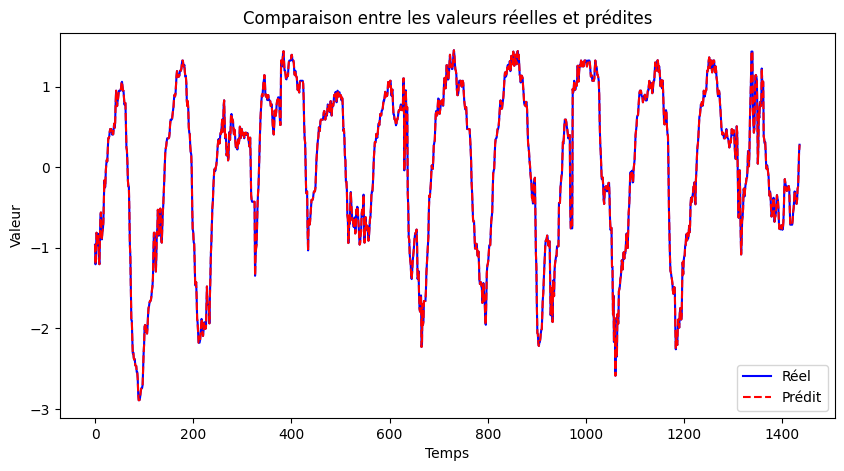

In [51]:
import matplotlib.pyplot as plt

def plot_predictions(y_true, y_pred):
    y_true = y_true.ravel()
    time_steps = np.arange(len(y_true))

    plt.figure(figsize=(10, 5))
    plt.plot(time_steps, y_true, label="Réel", color="blue")
    plt.plot(time_steps, y_pred.flatten(), label="Prédit", color="red", linestyle="dashed")
    plt.legend()
    plt.xlabel("Temps")
    plt.ylabel("Valeur")
    plt.title("Comparaison entre les valeurs réelles et prédites")
    plt.show()

# Test : superposition de Y_train à lui-même
plot_predictions(Y_train, Y_train)

17. Comme précédemment, réaliser l'optimisation de la cellule RNN à partir des données d'entraînement en utilisant la fonction optimize_rnn.

In [57]:


# Optimisation du RNN
W_xh, W_hh, b_h, W_hy, b_y = optimize_rnn(
    X_train_list, Y_train_list, h0, W_xh, W_hh, b_h, W_hy, b_y,
    epochs=epochs,
    learning_rate=learning_rate
)


Loss: 0.05640220592700244
Epoch 0/200 - Loss: 0.0537
Loss: 0.05369605036155794
Loss: 0.05601207662124315
Loss: 0.05641575250116307
Loss: 0.06414989546470004
Loss: 0.062000246548939916
Loss: 0.05977712765069702
Loss: 0.0553220092954956
Loss: 0.059408612970542646
Loss: 0.058222312683669626
Loss: 0.05662316584289388
Epoch 10/200 - Loss: 0.0587
Loss: 0.058744394790675405
Loss: 0.056438679508433336
Loss: 0.055877665109306425
Loss: 0.057763220102185577
Loss: 0.06146723355048642
Loss: 0.05810717058682487
Loss: 0.06013919975637052
Loss: 0.059469674892342124
Loss: 0.05778688330570126
Loss: 0.058848974419057176
Epoch 20/200 - Loss: 0.0601
Loss: 0.06008320821119481
Loss: 0.05753141155390981
Loss: 0.058025827875699244
Loss: 0.0555825064227023
Loss: 0.055141999140796545
Loss: 0.055039614555732606
Loss: 0.05558836842942668
Loss: 0.05595577636668434
Loss: 0.05634793436909399
Loss: 0.0555752461533973
Epoch 30/200 - Loss: 0.0555
Loss: 0.05545409297019381
Loss: 0.0539562441624142
Loss: 0.053700444520795

18. Tester votre RNN optimisé sur les données d'entraînement. Calculer la loss associée.

Loss train : 0.1137


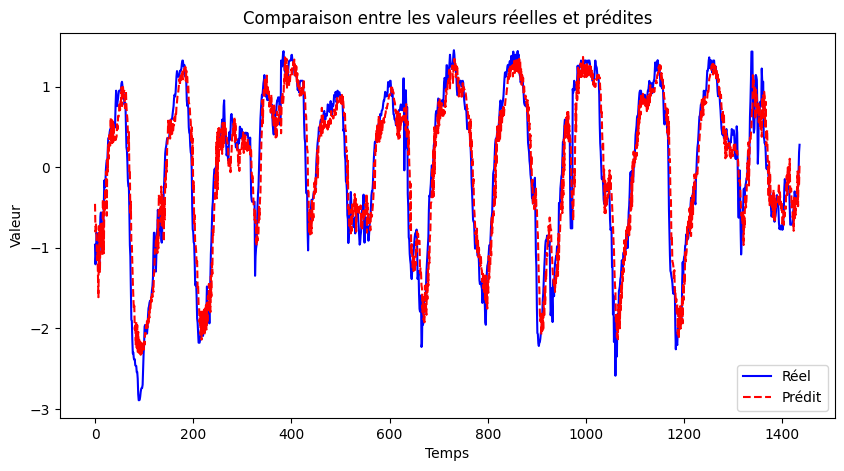

In [53]:
# Prédictions finales sur les données d'entraînement
y_pred_train, H = forward_rnn(X_train_list, h0, W_xh, W_hh, b_h, W_hy, b_y)

# Calcul de la loss
loss_train = compute_loss(y_pred_train, Y_train_list)
print(f"Loss train : {loss_train:.4f}")

# Visualisation
plot_predictions(Y_train, np.concatenate(y_pred_train))


19. Tester votre RNN sur les données de test. Calculer la loss associée. Quelle remarque faites vous ?

In [54]:

# Formatage des données de test
X_test_list = [X_test[i] for i in range(len(X_test))]
Y_test_list = [Y_test[i].reshape(1, 1) for i in range(len(Y_test))]

# Prédictions finales sur les données de test
y_pred_test, H = forward_rnn(X_test_list, h0, W_xh, W_hh, b_h, W_hy, b_y)

# Calcul de la loss
loss_test = compute_loss(y_pred_test, Y_test_list)
print(f"Loss train : {loss_train:.4f}")
print(f"Loss test  : {loss_test:.4f}")




Loss train : 0.1137
Loss test  : 0.1157


20. Utiliser la fonction plot_predictions pour afficher sur le même graphique, les valeurs prédites et les valeurs réelles

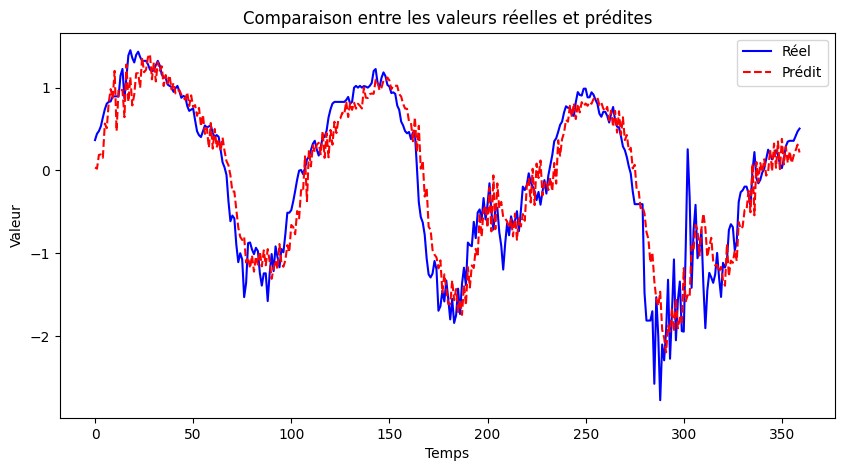

In [55]:
# Affichage des résultats sur les données de test
plot_predictions(Y_test, np.concatenate(y_pred_test))



21. Jouer sur les hyperparamètres du modèle pour oserver l'impact sur votre prédiction

Loss: 0.7846987735469044
Epoch 0/200 - Loss: 1.1639
Loss: 1.1639050499538792
Loss: 1.0055626212568909
Loss: 1.1219508814233083
Loss: 0.5355701540833924
Loss: 0.3183967085716248
Loss: 0.25561818833566274
Loss: 0.2085514037425111
Loss: 0.18911452070801474
Loss: 0.17665392863757254
Loss: 0.17083977609123224
Epoch 10/200 - Loss: 0.1527
Loss: 0.1526748147007939
Loss: 0.16787830708013032
Loss: 0.13490290621060333
Loss: 0.13095881581695154
Loss: 0.13143922010487946
Loss: 0.13276716216531864
Loss: 0.13619234764278995
Loss: 0.14212671385001677
Loss: 0.11973481711413644
Loss: 0.11045492721952883
Epoch 20/200 - Loss: 0.1120
Loss: 0.11196677817854653
Loss: 0.11632450196198406
Loss: 0.10901316853572302
Loss: 0.1276493171432846
Loss: 0.10509836013918196
Loss: 0.10438848464233438
Loss: 0.10493955592430824
Loss: 0.10012175130408513
Loss: 0.09846006445966195
Loss: 0.10395553460098961
Epoch 30/200 - Loss: 0.0973
Loss: 0.09728371981138076
Loss: 0.09280621379058134
Loss: 0.09919916852174653
Loss: 0.091721

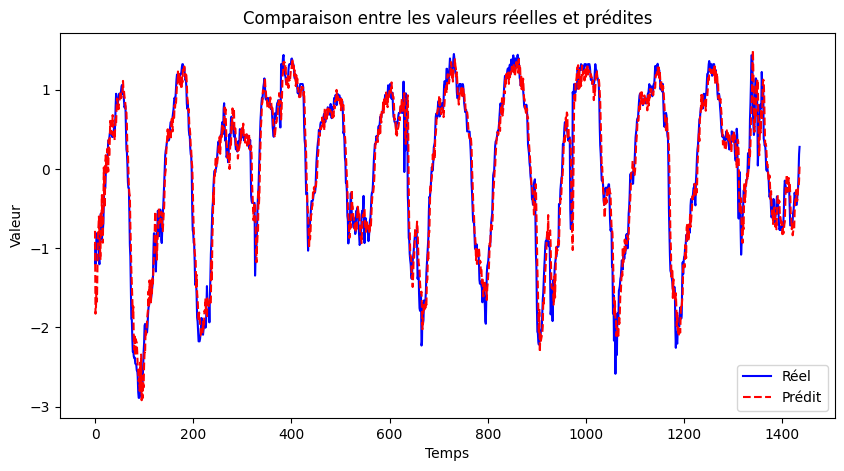

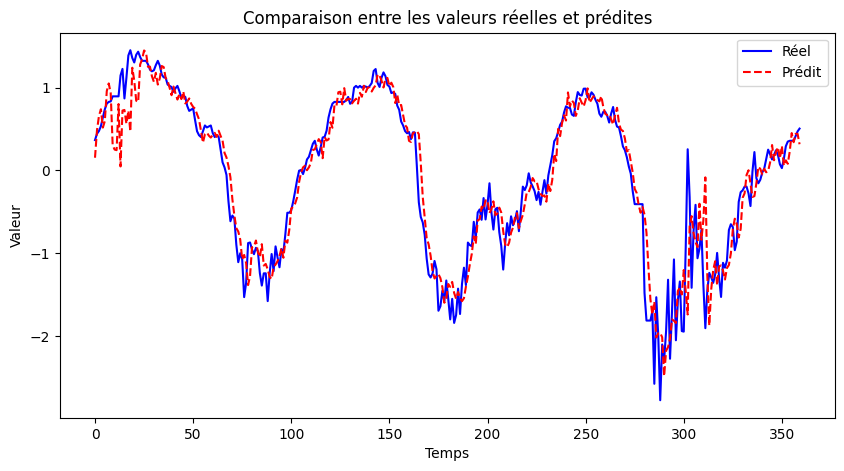

In [56]:
# Hyperparamètres à tester
h_size        = 150
x_size        = 4
y_size        = 1
learning_rate = 0.005
epochs        = 200

# Réinitialisation des poids
W_xh = np.random.randn(h_size, x_size) * np.sqrt(2.0 / sum((h_size, x_size)))
W_hh = np.random.randn(h_size, h_size) * np.sqrt(2.0 / sum((h_size, x_size)))
W_hy = np.random.randn(y_size, h_size) * np.sqrt(2.0 / sum((y_size, h_size)))
b_h  = np.zeros((h_size, 1))
b_y  = np.zeros((y_size, 1))
h0   = np.zeros((h_size, 1))

# Optimisation
W_xh, W_hh, b_h, W_hy, b_y = optimize_rnn(
    X_train_list, Y_train_list, h0, W_xh, W_hh, b_h, W_hy, b_y,
    epochs=epochs,
    learning_rate=learning_rate
)

# Évaluation
y_pred_train, _ = forward_rnn(X_train_list, h0, W_xh, W_hh, b_h, W_hy, b_y)
y_pred_test, _  = forward_rnn(X_test_list,  h0, W_xh, W_hh, b_h, W_hy, b_y)

print(f"Loss train : {compute_loss(y_pred_train, Y_train_list):.4f}")
print(f"Loss test  : {compute_loss(y_pred_test,  Y_test_list):.4f}")

plot_predictions(Y_train, np.concatenate(y_pred_train))
plot_predictions(Y_test,  np.concatenate(y_pred_test))

Dans cette section, nous testons l'impact des hyperparamètres sur les performances du RNN.
Nous faisons varier h_size, learning_rate et epochs pour observer leur effet sur la loss
et sur la qualité des prédictions.